In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
BASE_DIR = Path.cwd()

EDGE_FILE = BASE_DIR / "facebook_friendships_full_export.csv"
EMBEDDING_OUTPUT = BASE_DIR / "node2vec_embeddings.csv"
RECOMMEND_OUTPUT = BASE_DIR / "node2vec_recommendations_all_users.csv"

TOP_K = 20

DIMENSIONS = 128
WALK_LENGTH = 30
NUM_WALKS = 200
WINDOW = 10
MIN_COUNT = 1
WORKERS = 4


In [4]:
df = pd.read_csv(EDGE_FILE)

required_cols = {"startUserId", "endUserId"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

print("Shape:", df.shape)
df.head()


Shape: (88332, 2)


,startUserId,endUserId
0,07138d00-6a58-5657-9a3e-947ced97b680,c9c2f07d-c2c2-5a18-97d9-d87558fe3340
1,07138d00-6a58-5657-9a3e-947ced97b680,d3c501a9-6296-5f2a-932a-35c7e8d62c58
2,07138d00-6a58-5657-9a3e-947ced97b680,d5e0f052-1c61-546d-a69b-b07d095edc8a
3,07138d00-6a58-5657-9a3e-947ced97b680,d61d78e3-9656-5aa8-9c84-8233617d0b06
4,07138d00-6a58-5657-9a3e-947ced97b680,d6225b07-19ce-5373-b67a-28e5753f1a36


In [5]:
G = nx.Graph()

for _, row in df.iterrows():
    u = str(row["startUserId"]).strip()
    v = str(row["endUserId"]).strip()

    if not u or not v or u == v:
        continue

    G.add_edge(u, v)

print("Total nodes:", G.number_of_nodes())
print("Total edges:", G.number_of_edges())


Total nodes: 4098
Total edges: 88332


In [6]:
node2vec = Node2Vec(
    G,
    dimensions=DIMENSIONS,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    workers=WORKERS,
    p=1,
    q=1,
    quiet=False,
)

model = node2vec.fit(
    window=WINDOW,
    min_count=MIN_COUNT,
    batch_words=4,
)

print("Training completed.")


Computing transition probabilities:   0%|          | 0/4098 [00:00<?, ?it/s]

Training completed.


In [7]:
# Lưu embedding
embedding_rows = []

for node in G.nodes():
    vector = model.wv[str(node)]
    embedding_rows.append([node] + vector.tolist())

embedding_columns = ["userId"] + [f"dim_{i}" for i in range(DIMENSIONS)]
embedding_df = pd.DataFrame(embedding_rows, columns=embedding_columns)

embedding_df.to_csv(EMBEDDING_OUTPUT, index=False, encoding="utf-8")
print(f"Saved embeddings to: {EMBEDDING_OUTPUT}")

embedding_df.head()


Saved embeddings to: c:\Users\Thinh\Documents\Khóa luận TN\SanPham_BaoCao\Data_Train_HeGoiY_Now\node2vec_embeddings.csv


,userId,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_118,dim_119,dim_120,dim_121,dim_122,dim_123,dim_124,dim_125,dim_126,dim_127
0,07138d00-6a58-5657-9a3e-947ced97b680,-0.046690,-0.045253,0.616447,0.725284,0.457210,-0.019922,-0.118473,0.339141,-0.242546,...,0.075280,-0.041030,-0.330404,-0.339748,0.136331,-0.018007,-0.267361,-0.221842,-0.009989,0.091003
1,c9c2f07d-c2c2-5a18-97d9-d87558fe3340,-0.020139,-0.266199,0.748798,0.693238,0.428560,0.035808,-0.140409,0.391886,-0.192424,...,0.000772,-0.063526,-0.276330,-0.351463,0.121915,0.023155,-0.115329,-0.151048,-0.025211,0.066190
2,d3c501a9-6296-5f2a-932a-35c7e8d62c58,-0.169155,-0.236977,0.621034,0.643771,0.533833,-0.221185,-0.099670,0.460991,-0.254240,...,0.253891,-0.125781,-0.257413,-0.301847,0.236776,0.018325,-0.129119,-0.237380,-0.166146,-0.113021
3,d5e0f052-1c61-546d-a69b-b07d095edc8a,-0.046833,-0.112507,0.621684,0.552190,0.317610,0.023195,-0.160147,0.258421,-0.141631,...,0.255845,-0.121860,-0.345742,-0.237117,0.248666,0.191025,-0.133898,-0.118857,0.021318,0.013491
4,d61d78e3-9656-5aa8-9c84-8233617d0b06,-0.285096,-0.115137,0.580358,0.658135,0.315527,0.113124,0.018482,0.124783,-0.189675,...,0.293621,-0.098402,-0.324187,-0.222372,0.236911,0.082322,-0.153687,-0.040946,-0.082101,0.030919


In [8]:
# chuẩn bị ma trận similarity
all_nodes = list(G.nodes())
all_vectors = np.array([model.wv[node] for node in all_nodes])

similarity_matrix = cosine_similarity(all_vectors, all_vectors)

print("Full similarity matrix shape:", similarity_matrix.shape)

# lấy 10 user đầu để xem minh họa
sample_nodes = all_nodes[:10]
sample_indices = [all_nodes.index(node) for node in sample_nodes]

sample_matrix = similarity_matrix[np.ix_(sample_indices, sample_indices)]

sample_df = pd.DataFrame(
    sample_matrix,
    index=sample_nodes,
    columns=sample_nodes
)

sample_df



Full similarity matrix shape: (4098, 4098)


,07138d00-6a58-5657-9a3e-947ced97b680,c9c2f07d-c2c2-5a18-97d9-d87558fe3340,d3c501a9-6296-5f2a-932a-35c7e8d62c58,d5e0f052-1c61-546d-a69b-b07d095edc8a,d61d78e3-9656-5aa8-9c84-8233617d0b06,d6225b07-19ce-5373-b67a-28e5753f1a36,e584f4b6-524c-58a1-9f6e-f191a1a1e3ef,e9014989-08ef-507c-91f5-74e7ffaea780,edad0c10-bab0-5b87-acb9-8269c111894b,f7c4cd1c-faf3-5148-bc43-093dd1bbcb5e
07138d00-6a58-5657-9a3e-947ced97b680,1.000000,0.879593,0.908921,0.867672,0.920822,0.930693,0.875999,0.913698,0.749267,0.931889
c9c2f07d-c2c2-5a18-97d9-d87558fe3340,0.879593,1.000000,0.852151,0.849467,0.868705,0.867329,0.847533,0.852793,0.709383,0.882387
d3c501a9-6296-5f2a-932a-35c7e8d62c58,0.908921,0.852151,1.000000,0.860920,0.880719,0.870228,0.827277,0.894138,0.723575,0.920136
d5e0f052-1c61-546d-a69b-b07d095edc8a,0.867672,0.849467,0.860920,1.000000,0.868917,0.862169,0.827849,0.880218,0.715527,0.894962
d61d78e3-9656-5aa8-9c84-8233617d0b06,0.920822,0.868705,0.880719,0.868917,1.000000,0.940401,0.871859,0.903288,0.757250,0.942062
d6225b07-19ce-5373-b67a-28e5753f1a36,0.930693,0.867329,0.870228,0.862169,0.940401,1.000000,0.894867,0.915596,0.789777,0.931970
e584f4b6-524c-58a1-9f6e-f191a1a1e3ef,0.875999,0.847533,0.827277,0.827849,0.871859,0.894867,1.000000,0.860381,0.778861,0.876474
e9014989-08ef-507c-91f5-74e7ffaea780,0.913698,0.852793,0.894138,0.880218,0.903288,0.915596,0.860381,1.000000,0.737699,0.926774
edad0c10-bab0-5b87-acb9-8269c111894b,0.749267,0.709383,0.723575,0.715527,0.757250,0.789777,0.778861,0.737699,1.000000,0.754048
f7c4cd1c-faf3-5148-bc43-093dd1bbcb5e,0.931889,0.882387,0.920136,0.894962,0.942062,0.931970,0.876474,0.926774,0.754048,1.000000


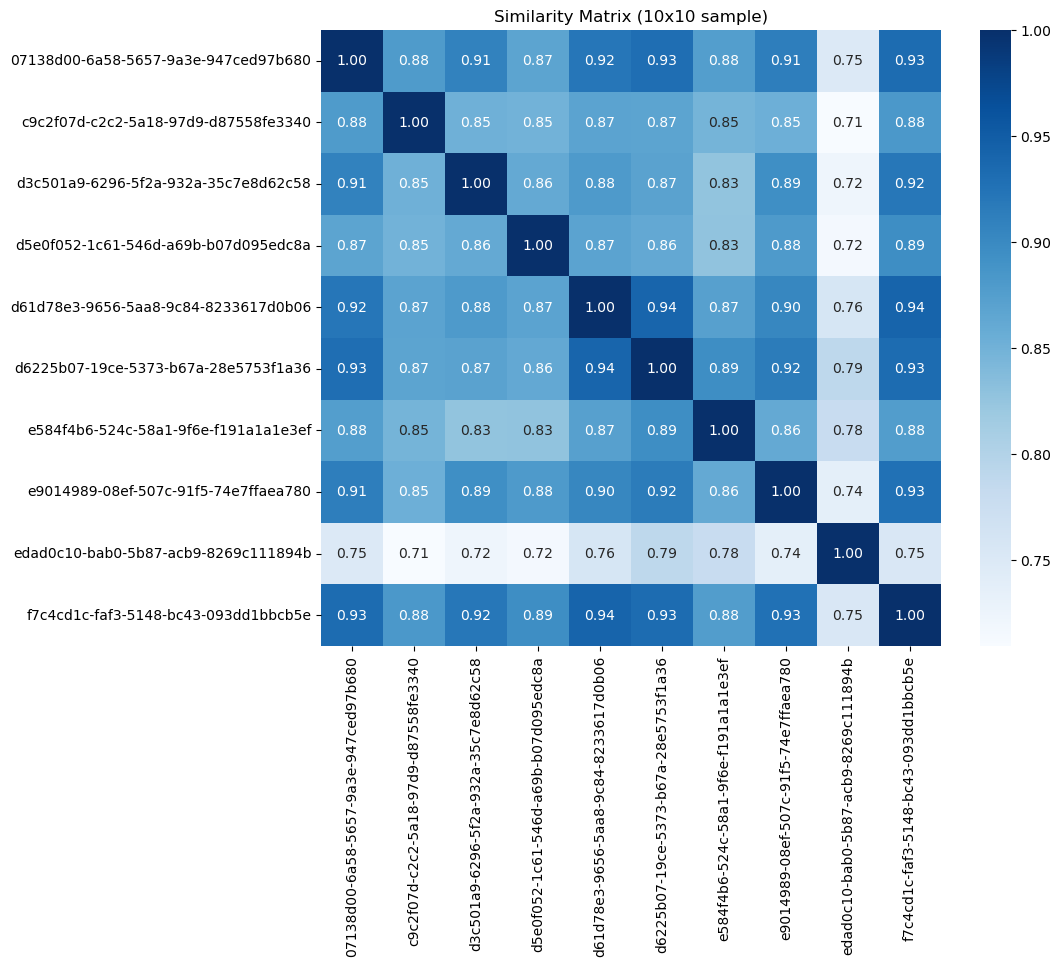

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(sample_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Similarity Matrix (10x10 sample)")
plt.show()


In [10]:
# sinh gợi ý cho tất cả user
recommendation_rows = []

node_to_index = {node: idx for idx, node in enumerate(all_nodes)}

for user_id in all_nodes:
    user_idx = node_to_index[user_id]
    scores = similarity_matrix[user_idx]

    existing_friends = set(G.neighbors(user_id))
    blocked_nodes = existing_friends | {user_id}

    candidates = []
    for other_id, score in zip(all_nodes, scores):
        if other_id in blocked_nodes:
            continue
        candidates.append((other_id, float(score)))

    candidates.sort(key=lambda x: x[1], reverse=True)
    top_k = candidates[:TOP_K]

    for rank, (recommended_id, score) in enumerate(top_k, start=1):
        recommendation_rows.append([
            user_id,
            recommended_id,
            rank,
            score
        ])

print("Total recommendation rows:", len(recommendation_rows))


Total recommendation rows: 81960


In [11]:
# lưu toàn bộ gợi ý
recommend_df = pd.DataFrame(
    recommendation_rows,
    columns=["userId", "recommendedUserId", "rank", "similarityScore"]
)

recommend_df.to_csv(RECOMMEND_OUTPUT, index=False, encoding="utf-8")
print(f"Saved recommendations to: {RECOMMEND_OUTPUT}")

recommend_df.head(20)


Saved recommendations to: c:\Users\Thinh\Documents\Khóa luận TN\SanPham_BaoCao\Data_Train_HeGoiY_Now\node2vec_recommendations_all_users.csv


,userId,recommendedUserId,rank,similarityScore
0,07138d00-6a58-5657-9a3e-947ced97b680,07390467-e107-5c4e-903a-9e695185e86a,1,0.921900
1,07138d00-6a58-5657-9a3e-947ced97b680,46b2c790-991f-5485-a785-fc006cd5140a,2,0.915974
2,07138d00-6a58-5657-9a3e-947ced97b680,8ece7d96-12e8-58ba-abe1-9ab694881d48,3,0.904369
3,07138d00-6a58-5657-9a3e-947ced97b680,47b418a3-b905-538c-8383-ba461d4d5364,4,0.892682
4,07138d00-6a58-5657-9a3e-947ced97b680,3159b034-5739-52a8-b801-707dccdacdd0,5,0.892096
5,07138d00-6a58-5657-9a3e-947ced97b680,da5185d6-9414-5665-85cd-64840a1ab2ad,6,0.887517
6,07138d00-6a58-5657-9a3e-947ced97b680,7b23ea2e-aa6b-5260-a13a-a32247fa7167,7,0.883313
7,07138d00-6a58-5657-9a3e-947ced97b680,26248807-de45-5579-9123-42b3e2aaaa24,8,0.881777
8,07138d00-6a58-5657-9a3e-947ced97b680,05117229-b460-558b-8bb6-2c325cc52ea5,9,0.881247
9,07138d00-6a58-5657-9a3e-947ced97b680,711f3f2d-ede7-56e8-aa36-7a29c5a21066,10,0.871689


In [5]:
# xem thử 1 user cụ thể
sample_user_id = "2901fc71-a8a0-4634-a6af-6a0d980430d7"

recommend_df[recommend_df["userId"] == sample_user_id].head(20)


NameError: name 'recommend_df' is not defined

In [3]:
recommend_df = pd.read_csv("node2vec_recommendations_all_users.csv")
recommend_df.head()


NameError: name 'pd' is not defined

KIỂM TRA CHẤT LƯỢNG KẾT QUẢ

In [6]:
recommend_df = pd.read_csv("node2vec_recommendations_all_users.csv")
users_df = pd.read_csv("user_now.csv")

print("recommend_df shape:", recommend_df.shape)
print("users_df shape:", users_df.shape)

recommend_df.head()


recommend_df shape: (81960, 4)
users_df shape: (4121, 14)


,userId,recommendedUserId,rank,similarityScore
0,07138d00-6a58-5657-9a3e-947ced97b680,07390467-e107-5c4e-903a-9e695185e86a,1,0.921900
1,07138d00-6a58-5657-9a3e-947ced97b680,46b2c790-991f-5485-a785-fc006cd5140a,2,0.915974
2,07138d00-6a58-5657-9a3e-947ced97b680,8ece7d96-12e8-58ba-abe1-9ab694881d48,3,0.904369
3,07138d00-6a58-5657-9a3e-947ced97b680,47b418a3-b905-538c-8383-ba461d4d5364,4,0.892682
4,07138d00-6a58-5657-9a3e-947ced97b680,3159b034-5739-52a8-b801-707dccdacdd0,5,0.892096


In [7]:
recommend_view_df = recommend_df.merge(
    users_df[["userId", "displayName", "email", "avatarUrl", "location"]],
    on="userId",
    how="left"
).rename(columns={
    "displayName": "userDisplayName",
    "email": "userEmail",
    "avatarUrl": "userAvatarUrl",
    "location": "userLocation"
})

recommend_view_df = recommend_view_df.merge(
    users_df[["userId", "displayName", "email", "avatarUrl", "location"]],
    left_on="recommendedUserId",
    right_on="userId",
    how="left"
).rename(columns={
    "displayName": "recommendedDisplayName",
    "email": "recommendedEmail",
    "avatarUrl": "recommendedAvatarUrl",
    "location": "recommendedLocation"
})


In [8]:
recommend_view_df = recommend_view_df.drop(columns=["userId_y"])
recommend_view_df = recommend_view_df.rename(columns={"userId_x": "userId"})

recommend_view_df.head(20)


,userId,recommendedUserId,rank,similarityScore,userDisplayName,userEmail,userAvatarUrl,userLocation,recommendedDisplayName,recommendedEmail,recommendedAvatarUrl,recommendedLocation
0,07138d00-6a58-5657-9a3e-947ced97b680,07390467-e107-5c4e-903a-9e695185e86a,1,0.921900,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Lý Tuấn Duy,fb_1454@facebook-combined.local,NaN,"Da Nang, Viet Nam"
1,07138d00-6a58-5657-9a3e-947ced97b680,46b2c790-991f-5485-a785-fc006cd5140a,2,0.915974,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Hoàng Anh Giang,fb_1824@facebook-combined.local,NaN,"Ha Noi, Viet Nam"
2,07138d00-6a58-5657-9a3e-947ced97b680,8ece7d96-12e8-58ba-abe1-9ab694881d48,3,0.904369,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Phan Bảo Châu,fb_898@facebook-combined.local,NaN,"Bien Hoa, Viet Nam"
3,07138d00-6a58-5657-9a3e-947ced97b680,47b418a3-b905-538c-8383-ba461d4d5364,4,0.892682,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Mai Khánh Duy,fb_1495@facebook-combined.local,NaN,"Da Lat, Viet Nam"
4,07138d00-6a58-5657-9a3e-947ced97b680,3159b034-5739-52a8-b801-707dccdacdd0,5,0.892096,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Đinh Thị Duy,fb_1316@facebook-combined.local,NaN,"Vung Tau, Viet Nam"
5,07138d00-6a58-5657-9a3e-947ced97b680,da5185d6-9414-5665-85cd-64840a1ab2ad,6,0.887517,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Bùi Văn Dũng,fb_969@facebook-combined.local,NaN,"Quy Nhon, Viet Nam"
6,07138d00-6a58-5657-9a3e-947ced97b680,7b23ea2e-aa6b-5260-a13a-a32247fa7167,7,0.883313,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Lý Phúc Châu,fb_954@facebook-combined.local,NaN,"Nha Trang, Viet Nam"
7,07138d00-6a58-5657-9a3e-947ced97b680,26248807-de45-5579-9123-42b3e2aaaa24,8,0.881777,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Trần Thanh Dũng,fb_1081@facebook-combined.local,NaN,"Ho Chi Minh City, Viet Nam"
8,07138d00-6a58-5657-9a3e-947ced97b680,05117229-b460-558b-8bb6-2c325cc52ea5,9,0.881247,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Vũ Thanh Duy,fb_1406@facebook-combined.local,NaN,"Da Nang, Viet Nam"
9,07138d00-6a58-5657-9a3e-947ced97b680,711f3f2d-ede7-56e8-aa36-7a29c5a21066,10,0.871689,Lê Phúc Duy,fb_1582@facebook-combined.local,NaN,"Bien Hoa, Viet Nam",Phan Thị Giang,fb_1638@facebook-combined.local,NaN,"Nha Trang, Viet Nam"


In [9]:
sample_user_id = "b0de96c1-9442-450e-b9d2-9a0dcb4f363d"

recommend_view_df[
    recommend_view_df["userId"] == sample_user_id
][[
    "userId",
    "userDisplayName",
    "recommendedUserId",
    "recommendedDisplayName",
    "rank",
    "similarityScore"
]].head(20)


,userId,userDisplayName,recommendedUserId,recommendedDisplayName,rank,similarityScore
68740,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,59361a24-d074-4742-a96d-7de04931f62e,Nguyễn Phạm Lưu Ly,1,0.951617
68741,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,ba1412cc-f0c1-4580-9a77-c2afebf6abb8,Trung Kien,2,0.948109
68742,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,aad00062-7be0-44b2-866b-927a5fe71a04,System Admin,3,0.946954
68743,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,2353696a-aa33-4f3d-baf2-0270c11f7694,EC2 Access,4,0.946361
68744,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,08dd44ae-e4e6-4f29-b742-9d2490644228,Feed Check,5,0.945290
68745,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,3d5ede23-3acd-49c0-abba-b3ee8aadc88e,Văn Nguyễn,6,0.944739
68746,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,ed21806c-45c5-42ad-b332-5714798cbca8,Lưu Huyền,7,0.942459
68747,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,3459339c-fb36-4887-998b-b00b25543b6a,Lê Thị Nô,8,0.941966
68748,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,5e9ee67e-4e1e-48d9-a24a-3eb28dcdd1f4,User 27,9,0.939445
68749,b0de96c1-9442-450e-b9d2-9a0dcb4f363d,Nguyễn Mạnh Dũng,ace322fe-43ba-4883-9785-e2042e75ab17,User 45,10,0.934491


In [21]:
recommend_view_df.to_csv(
    "node2vec_recommendations_view.csv",
    index=False,
    encoding="utf-8"
)

print("Saved: node2vec_recommendations_view.csv")


Saved: node2vec_recommendations_view.csv
